In [113]:
import csv

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import sklearn.metrics as metrics

from tensorflow import keras
from keras.callbacks import EarlyStopping
from keras.models import Model, Sequential, load_model, save_model
from keras.layers import Activation, Dense, Input, Dropout, Flatten, BatchNormalization
from keras.optimizers import Adam
from keras.metrics import categorical_crossentropy, Precision, Recall
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from keras.regularizers import l2

from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score, accuracy_score, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

# Leitura dos registros de treinamento:

In [114]:
csv_path_training_gases = "Datasets/Ibrahim-dataset/SMOTE-Oversampled-119-dataset/train_samples.csv"
with open(csv_path_training_gases, mode = 'r') as file:
    csv_reader_training_gases = csv.reader(file)
    next(csv_reader_training_gases)

    train_samples = []
    for row in csv_reader_training_gases:
        train_samples.append([float(x) for x in row])
        
csv_path_training_faults = "Datasets/Ibrahim-dataset/SMOTE-Oversampled-119-dataset/train_labels.csv"
with open(csv_path_training_faults, mode = 'r') as file:
    csv_reader_training_faults = csv.reader(file)
    next(csv_reader_training_faults)

    train_labels = []
    for row in csv_reader_training_faults:
        train_labels.append(float(row[0]))

# Normalização dos treinos:

In [115]:



# Adiciona uma pequena constante para evitar log(0)
epsilon = 1e-10

# Normalização logarítmica dos gases
train_samples = np.array(train_samples)
scaled_train_samples = np.log(train_samples + epsilon)


scaler = RobustScaler()

# # normalização dos gases com robust scaler
# scaled_train_samples = scaler.fit_transform(train_samples)

# Normalização dos rótulos
train_labels = np.array(train_labels)
train_labels = train_labels.flatten()
int_scaled_train_labels = (train_labels.astype(float)).astype(int)
int_scaled_train_labels = np.array(int_scaled_train_labels)



# Criação do modelo da Rede neural:

In [116]:
def create_functional_model():
    model = Sequential([
        Input(shape=(5,)),
        Dense(32, activation='relu', kernel_regularizer=l2(0.001)), 
        BatchNormalization(),
        Dropout(0.5),
        Dense(16, activation='relu'),
        Dense(7, activation='softmax')
    ]) 

    model.compile(optimizer=Adam(learning_rate=0.002),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=500,
    mode='min',
    restore_best_weights=True
)

functional_model = create_functional_model()
history = functional_model.fit(scaled_train_samples, int_scaled_train_labels, validation_split=0.2, epochs=1300, batch_size=64, callbacks=[early_stopping], verbose=2)

Epoch 1/1300
9/9 - 1s - loss: 2.2242 - accuracy: 0.1992 - val_loss: 2.0942 - val_accuracy: 0.1654 - 766ms/epoch - 85ms/step
Epoch 2/1300
9/9 - 0s - loss: 1.9493 - accuracy: 0.2406 - val_loss: 1.8308 - val_accuracy: 0.1955 - 35ms/epoch - 4ms/step
Epoch 3/1300
9/9 - 0s - loss: 1.7966 - accuracy: 0.3289 - val_loss: 1.6574 - val_accuracy: 0.2857 - 37ms/epoch - 4ms/step
Epoch 4/1300
9/9 - 0s - loss: 1.6654 - accuracy: 0.3684 - val_loss: 1.5396 - val_accuracy: 0.4361 - 43ms/epoch - 5ms/step
Epoch 5/1300
9/9 - 0s - loss: 1.4805 - accuracy: 0.4586 - val_loss: 1.4432 - val_accuracy: 0.4662 - 38ms/epoch - 4ms/step
Epoch 6/1300
9/9 - 0s - loss: 1.4141 - accuracy: 0.4831 - val_loss: 1.3539 - val_accuracy: 0.5113 - 39ms/epoch - 4ms/step
Epoch 7/1300
9/9 - 0s - loss: 1.3583 - accuracy: 0.4962 - val_loss: 1.2790 - val_accuracy: 0.5714 - 37ms/epoch - 4ms/step
Epoch 8/1300
9/9 - 0s - loss: 1.3024 - accuracy: 0.5263 - val_loss: 1.2037 - val_accuracy: 0.6165 - 42ms/epoch - 5ms/step
Epoch 9/1300
9/9 - 0s 

# Plotagem das métricas de treinamento:

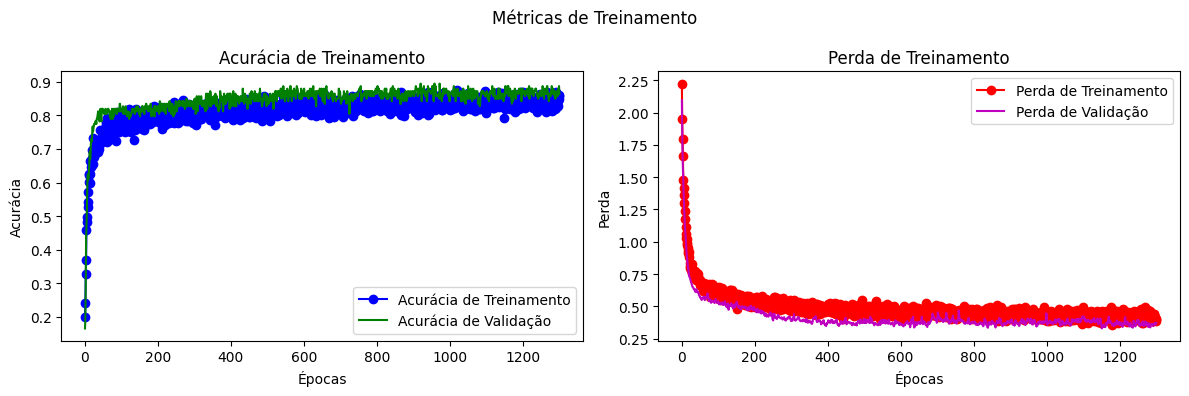

In [117]:
def plot_training_history(history):
    acc = history.history['accuracy']
    loss = history.history['loss']
    epochs = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Métricas de Treinamento')

    ax1.plot(epochs, acc, 'bo-', label='Acurácia de Treinamento')
    ax1.set_title('Acurácia de Treinamento')
    ax1.set_xlabel('Épocas')
    ax1.set_ylabel('Acurácia')
    ax1.legend()

    ax2.plot(epochs, loss, 'ro-', label='Perda de Treinamento')
    ax2.set_title('Perda de Treinamento')
    ax2.set_xlabel('Épocas')
    ax2.set_ylabel('Perda')
    ax2.legend()

    if 'val_accuracy' in history.history:
        val_acc = history.history['val_accuracy']
        val_loss = history.history['val_loss']
        ax1.plot(epochs, val_acc, 'g-', label='Acurácia de Validação')
        ax2.plot(epochs, val_loss, 'm-', label='Perda de Validação')
        ax1.legend()
        ax2.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Leitura dos registros de teste:


In [118]:
csv_path_testing_gases = "Datasets/Ibrahim-dataset/Gas-80-20-dataset/test_samples.csv"
with open(csv_path_testing_gases, mode = 'r') as file:
    csv_reader_testing_gases = csv.reader(file)
    next(csv_reader_testing_gases)
    
    test_samples = []
    for row in csv_reader_testing_gases:
        test_samples.append([float(x) for x in row])

csv_path_testing_faults = "Datasets/Ibrahim-dataset/Gas-80-20-dataset/test_labels.csv"
with open(csv_path_testing_faults, mode = 'r') as file:
    csv_reader_testing_faults = csv.reader(file)
    next(csv_reader_testing_faults)
    
    test_labels = []
    for row in csv_reader_testing_faults:
        test_labels.append(float(row[0]))

# Normalização dos testes:

In [119]:

# Normalização logarítmica dos gases
test_samples = np.array(test_samples)
scaled_test_samples = np.log(test_samples + epsilon)

# normalização dos gases de teste
# scaled_test_samples = scaler.transform(test_samples)

# normalização das rótulos de teste
test_labels = np.array(test_labels)
test_labels = test_labels.flatten()
int_scaled_test_labels = (test_labels.astype(float)).astype(int)
int_scaled_test_labels = np.array(int_scaled_test_labels)

# Teste e análise do modelo:

4/4 [==============================] - 0s 1ms/step
Balanced Accuracy: 0.8690
Acurácia no conjunto de teste: 0.8654
Perda no conjunto de teste: 0.4105

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.89      0.89      0.89         9
           2       0.91      0.67      0.77        15
           3       0.79      0.92      0.85        24
           4       0.94      0.94      0.94        18
           5       0.67      1.00      0.80         8
           6       1.00      0.67      0.80        15

    accuracy                           0.87       104
   macro avg       0.88      0.87      0.86       104
weighted avg       0.88      0.87      0.86       104



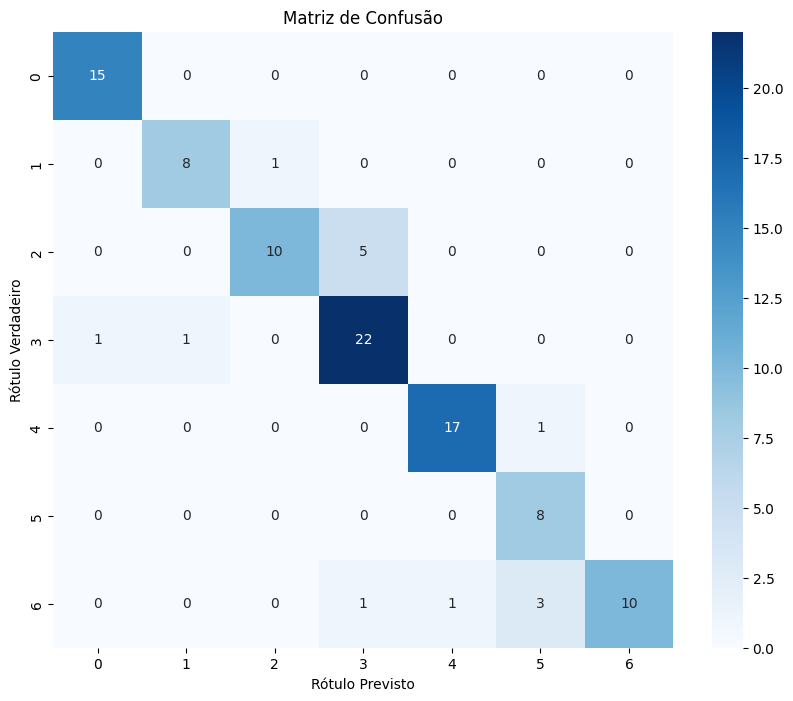

In [120]:

# realizando predições com o modelo treinado
y_pred = functional_model.predict(scaled_test_samples)
y_pred_classes = np.argmax(y_pred, axis=1)

# avaliando o modelo
test_loss, test_accuracy = functional_model.evaluate(scaled_test_samples, 
                                                   int_scaled_test_labels, 
                                                   verbose=0)
balanced_acc = balanced_accuracy_score(int_scaled_test_labels, y_pred_classes)
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(f"Acurácia no conjunto de teste: {test_accuracy:.4f}")
print(f"Perda no conjunto de teste: {test_loss:.4f}")
print("\nRelatório de Classificação:")
print(classification_report(int_scaled_test_labels, y_pred_classes, zero_division=0))

# matriz de confusão
cm = confusion_matrix(int_scaled_test_labels, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão')
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Previsto')
plt.show()
